# Simple Example using Simulated Data

To get started with StanBKT, use this example to explore the following concepts:

1. How to simulate data using `sim_simple_BKT`
2. How to instantiate a model for MCMC fitting.
3. How to specify priors and stan compile arguments.
4. How to fit the model to the data


## Simulate BKT data

The data generation process is based on the standard BKT model with population wide parameters.


In [1]:
from stanbkt.utils import sim_simple_BKT

In [2]:
# define ground truth BKT parameters for data simulation
N_KCS = 2  # we will simulate data for 2 KCs
bkt_params = {  # define BKT parameters for each KCs
    "prior": [0.4, 0.1],
    "learn": [0.04, 0.08],
    "forget": [0.01, 0.005],
    "guess": [0.1, 0.3],
    "slip": [0.05, 0.05],
}

In [3]:
data_df = sim_simple_BKT(
    n_students=30,  # 30 students
    n_problems=60,  # 60 problems
    n_kcs=2,  # 2 knowledge components
    frac=0.8,  # sample 80% of generated data (simulates missing data)
    rng_seed=1234,  # random seed for reproducibility
    **bkt_params,  # use the defined BKT parameters for data simulation
)

StanBKT expects data in a long format with four required columns:

1. Student ID: ID of the student
2. Problem ID: ID of the problem
3. Correctness: A binary indicator (1/0) of whether the student answered the problem correctly
4. Problem Order: The order in which a student attempted the problems (e.g., a timestamp)

If `KC ID` is not included in the DataFrame, StanBKT assumes all problems belong to the same KC.


In [4]:
data_df.head(10)

,student_id,problem_id,correct,timestamp,kc_id
0,stu_0,prob_0,0,2024-01-01 00:00:00,kc_1
1,stu_0,prob_1,0,2024-01-01 00:01:00,kc_1
2,stu_0,prob_2,0,2024-01-01 00:02:00,kc_1
3,stu_0,prob_4,0,2024-01-01 00:04:00,kc_0
4,stu_0,prob_6,0,2024-01-01 00:06:00,kc_0
5,stu_0,prob_7,1,2024-01-01 00:07:00,kc_0
6,stu_0,prob_8,1,2024-01-01 00:08:00,kc_0
7,stu_0,prob_9,1,2024-01-01 00:09:00,kc_0
8,stu_0,prob_11,1,2024-01-01 00:11:00,kc_0
9,stu_0,prob_13,1,2024-01-01 00:13:00,kc_0


Additionally, if column names differ from the expected names, StanBKT requires a mapping from expected column names to the actual DataFrame column names.


In [5]:
from stanbkt.utils import ColumnNames

# define column mapping for the data
# this will be used in subsequent calls such as model fitting and prediction
col_mapping = {
    ColumnNames.STUDENT_ID: "student_id",
    ColumnNames.PROBLEM_ID: "problem_id",
    ColumnNames.KC_ID: "kc_id",
    ColumnNames.CORRECTNESS: "correct",
}

## Define model


In [6]:
from stanbkt.models import StandardBKT
from stanbkt.fits import FitMethod
from stanbkt.utils import VerbosityLevel

### Defining the Model

The following code block creates a StandardBKT model (which includes the Forgetting parameter), that will be fit using MCMC.


In [7]:
model = StandardBKT(
    fit_method=FitMethod.MCMC,  # use MCMC for parameter estimation
    verbose=VerbosityLevel.WARN,  # only print warnings
)

### Fitting the Model

StanBKT compiles the underlying Stan code _lazily_ on the first fit call. Which means calling `model.fit(...)` for the first time will first compile the model and cache it in the platform specific cache directory (e.g. `.cache` on Linux). Instantiating a model with the same type (i.e. Standard, Grouped, etc.), `stan_compile_kwargs` and `cpp_compile_kwargs` will use the previously compiled model. See :ref: xyz for more information.

We can fit the model passing data for each KC individually or as a whole. Subsequently calling fit will _not_ remove previously fitted KCs, instead it will add additional fitted KCs to the model.

Fitting each KCs individually is particularly useful when we need different bayesian priors and stan fit options. Note. each fit method (i.e. MCMC, Variation Inference, Pathfinder or MLE) has different fit options (see :ref: xyz).

In this example, the default priors and MCMC fit options is used for for `kc_1` and custom priors and options for `kc_2`.


In [8]:
kc_0_df = data_df[data_df["kc_id"] == "kc_0"]
# fit the model to the data for kc_0, using default priors and default MCMC settings
model.fit(kc_0_df)

11:14:57 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

11:14:59 - cmdstanpy - INFO - CmdStan done processing.


StandardBKT(fit_method=<FitMethod.MCMC: 'mcmc'>, verbose=<VerbosityLevel.WARN: 1>, is_fitted=True)

We define the Bayesian priors for `kc_2` based on domain knowledge and uncertainty in that knowledge. These priors are on the logit scale and are modeled as normal distributions.
The inverse logit function $f(x) = \frac{1}{1+e^{-x}}$, transforms the logits into the probability scale.

It is important to note that the `guess` and `slip` parameters are on the _half-logit_ scale, i.e. these parameters have a maximum value of 0.5 on the probability scale. This is done to ensure identifiability and prevent model degeneracy (see :ref: xyz).

Hence, for either the learn or forget parameter, a prior of $\mathcal{N}(0, 2)$ would correspond to a prior mean probability of 0.5 and a 95% prior probability values between 0.0194 and 0.980.

However, for either the guess and slip parameters, a prior of $\mathcal{N}(0, 2)$ would correspond to a prior mean probability of 0.25 and a 95% prior probability values between 0.0097 and 0.49. Again, this is due to the fact that guess and slip parameters are on the _half-logit_ scale.

Any parameter without specified priors will use the default priors, alternatively, one can choose to use no priors i.e., improper non-informative prior, which is modeled as a uniform distribution over the parameter space. To do this, explicitly set the parameters as `None` e.g. `BayesianPriors(pi_know_mu=None, pi_know_std=None)`, or pass in `use_defaults=False`, which initializes all non-specified parameters as `None`.


In [9]:
from stanbkt.models import StandardPriors

# define bayesian priors for prior knowledge and guess parameters
# any parameters not specified here will use the default priors
# to use Improper non-informative priors, i.e., uniform distribution over the parameter space,
# explicitly pass None, or pass in use_defaults=False in the StandardPriors constructor (i.e. StandardPriors(use_defaults=False))
priors_kc_1 = StandardPriors(
    pi_know_mu=0,
    pi_know_std=2,  # prior for initial knowledge (pi_know)
    guess_mu=0,
    guess_std=2,  # prior for guess parameter
)

In [10]:
from stanbkt.fits import MCMCFitOptions

fit_opts = MCMCFitOptions(
    seed=1234,  # seed for reproducibility
    iter_warmup=500,  # number of warmup iterations for MCMC
    iter_sampling=500,  # number of sampling iterations for MCMC
)

In [11]:
kc_1_df = data_df[data_df["kc_id"] == "kc_1"]
# fit the model to the data for kc_1, using the defined priors and MCMC settings
model.fit(kc_1_df, stan_fit_options=fit_opts, priors=priors_kc_1)

11:14:59 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1000 [00:00<?, ?it/s, (Warmup)]

11:15:01 - cmdstanpy - INFO - CmdStan done processing.


StandardBKT(fit_method=<FitMethod.MCMC: 'mcmc'>, verbose=<VerbosityLevel.WARN: 1>, is_fitted=True)

Alternatively, the entire dataframe can be passed to fit the model all Kcs in the data `model.fit(data_df, ...)`


In [12]:
model.summary()

Mean      MCSE    StdDev       MAD  \
kc_id parameter                                                          
kc_0  lp__                   -236.912000  0.036365  1.604140  1.422550   
      logit_pi_know_group[1]   -0.445610  0.006437  0.441265  0.432285   
      logit_learn_group[1]     -2.711160  0.005143  0.322566  0.320049   
      logit_forget_group[1]    -4.588980  0.009253  0.576608  0.568585   
      logit_guess_group[1]     -1.604210  0.004213  0.287789  0.290034   
      logit_slip_group[1]      -2.180530  0.004495  0.285021  0.269611   
      pi_know[1]                0.395075  0.001466  0.101158  0.101823   
      learn[1]                  0.064915  0.000281  0.018786  0.018746   
      forget[1]                 0.011653  0.000092  0.006222  0.005670   
      guess[1]                  0.085580  0.000287  0.019964  0.020350   
      slip[1]                   0.052194  0.000189  0.012806  0.012620   
kc_1  lp__                   -340.297000  0.060539  1.723020  1.493720   
      logit_pi_know_group[1]   -1.500390  0.015286  0.647648  0.582706   
      logit_learn_group[1]     -2.176250  0.005037  0.244840  0.249966   
      logit_forget_group[1]    -4.456850  0.015707  0.623420  0.561498   
      logit_guess_group[1]     -0.002974  0.005936  0.280825  0.280056   
      logit_slip_group[1]      -2.132630  0.006200  0.271768  0.277372   
      pi_know[1]                0.200326  0.002015  0.092390  0.090590   
      learn[1]                  0.104065  0.000465  0.022534  0.022647   
      forget[1]                 0.013473  0.000146  0.007351  0.006525   
      guess[1]                  0.249612  0.000724  0.034398  0.034903   
      slip[1]                   0.054342  0.000287  0.012875  0.013260   

                                    2.5%         50%       97.5%  ESS_bulk  \
kc_id parameter                                                              
kc_0  lp__                   -240.863000 -236.587000 -234.814000  1999.530   
      logit_pi_know_group[1]   -1.306560   -0.448010    0.430112  4702.520   
      logit_learn_group[1]     -3.407340   -2.693420   -2.142760  4231.740   
      logit_forget_group[1]    -5.859910   -4.547700   -3.578490  4207.500   
      logit_guess_group[1]     -2.208330   -1.593260   -1.077050  4795.970   
      logit_slip_group[1]      -2.779010   -2.158010   -1.662600  4452.090   
      pi_know[1]                0.213063    0.389834    0.605900  4702.540   
      learn[1]                  0.032067    0.063363    0.105010  4231.740   
      forget[1]                 0.002843    0.010481    0.027160  4207.500   
      guess[1]                  0.049502    0.084463    0.127032  4795.940   
      slip[1]                   0.029235    0.051793    0.079707  4452.090   
kc_1  lp__                   -344.523000 -339.917000 -338.091000   826.701   
      logit_pi_know_group[1]   -2.934170   -1.437650   -0.369026  2003.180   
      logit_learn_group[1]     -2.685710   -2.163220   -1.723290  2433.350   
      logit_forget_group[1]    -5.868850   -4.394220   -3.438270  2194.710   
      logit_guess_group[1]     -0.524340   -0.003166    0.547373  2301.440   
      logit_slip_group[1]      -2.671390   -2.123150   -1.640220  1990.850   
      pi_know[1]                0.050490    0.191910    0.408776  2003.160   
      learn[1]                  0.063822    0.103102    0.151448  2433.320   
      forget[1]                 0.002818    0.012198    0.031121  2194.710   
      guess[1]                  0.185919    0.249605    0.316763  2301.420   
      slip[1]                   0.032341    0.053433    0.081218  1990.840   

                              ESS_tail     R_hat  
kc_id parameter                                   
kc_0  lp__                     2733.78  1.001580  
      logit_pi_know_group[1]   3163.94  0.999969  
      logit_learn_group[1]     2562.92  1.000380  
      logit_forget_group[1]    2724.21  1.001550  
      logit_guess_group[1]     2804.12  1.000670  
      logit_slip_group[1]    

In [13]:
bkt_params

{'prior': [0.4, 0.1],
 'learn': [0.04, 0.08],
 'forget': [0.01, 0.005],
 'guess': [0.1, 0.3],
 'slip': [0.05, 0.05]}

## Predictions

StanBKT offers two methods to generate predictions for the hidden state probabilities (i.e. the probability that a student knows a skill) and correctness:

- **Point Estimates**: Uses a Bayesian point estimate (mean, median, or mode) of the parameter posteriors. Implemented in Python with Numba JIT compilation for fast inference. Useful for quick evaluation and debugging.
- **Posterior**: Uses the full posterior to generate posterior predictive distributions via Stan's `generated quantities` block. This propagates parameter uncertainty through to the predictions.

Additionally, there are two types of predictions available:

1. **Unsmoothed (online / forward)**: At each time step $t$, the mastery estimate $P(\text{know}_t \mid \text{obs}_1, \ldots, \text{obs}_{t-1})$ conditions only on _previous_ observations. This is the standard BKT forward pass and reflects what would be known in a live tutoring system.
2. **Smoothed (offline / forward-backward)**: At each time step $t$, the mastery estimate $P(\text{know}_t \mid \text{obs}_1, \ldots, \text{obs}_T)$ conditions on _all_ observations (past and future). This uses the HMM forward-backward algorithm and is more accurate in retrospect, but requires the full sequence to be observed first.

Both prediction methods return a long-format `pd.DataFrame` with columns `kc_id`, `student_id`, `problem_id`, `pKnow`, `pCorrectness`, and `correct`.


### Bayesian point-estimate based (numba implementation)


#### Unsmoothed (Online) Predictions

`model.predict(...)` runs the standard BKT forward pass. For each time step, the mastery estimate only uses responses from _prior_ time steps.


In [14]:
# Unsmoothed (online) point-estimate predictions
# pKnow at time t is conditioned on observations 1 ... t-1 (forward pass only)
predictions = model.predict(data_df, column_mapping=col_mapping)
predictions.head(23)

,kc_id,student_id,problem_id,pKnow,pCorrectness,correct
0,kc_1,stu_0,prob_0,0.200326,0.389048,0
1,kc_1,stu_0,prob_1,0.119789,0.332990,0
2,kc_1,stu_0,prob_2,0.112677,0.328040,0
3,kc_1,stu_0,prob_14,0.112106,0.327643,1
4,kc_1,stu_0,prob_17,0.389600,0.520791,0
5,kc_1,stu_0,prob_18,0.143052,0.349183,0
6,kc_1,stu_0,prob_20,0.114606,0.329383,1
7,kc_1,stu_0,prob_24,0.394424,0.524149,0
8,kc_1,stu_0,prob_25,0.143813,0.349713,1
9,kc_1,stu_0,prob_26,0.447242,0.560913,1


#### Smoothed (Offline) Predictions

`model.predict_smoothed_states(...)` runs the forward-backward algorithm. For each time step, the mastery estimate uses _all_ observations in the sequence, giving a more accurate retrospective view of mastery.


In [15]:
# Smoothed (offline) point-estimate predictions
# pKnow at time t is conditioned on all observations 1 ... T (forward-backward pass)
smoothed_predictions = model.predict_smoothed(data_df, column_mapping=col_mapping)
smoothed_predictions.head(n=23)

,kc_id,student_id,problem_id,pKnow,pCorrectness,correct
0,kc_1,stu_0,prob_0,0.000309,0.249827,0
1,kc_1,stu_0,prob_1,0.000250,0.249786,0
2,kc_1,stu_0,prob_2,0.001194,0.250442,0
3,kc_1,stu_0,prob_14,0.013183,0.258787,1
4,kc_1,stu_0,prob_17,0.007438,0.254789,0
5,kc_1,stu_0,prob_18,0.022183,0.265052,0
6,kc_1,stu_0,prob_20,0.214357,0.398814,1
7,kc_1,stu_0,prob_24,0.253830,0.426289,0
8,kc_1,stu_0,prob_25,0.821093,0.821131,1
9,kc_1,stu_0,prob_26,0.956724,0.915537,1


### Posterior Predictions

The following functions with `_posterior_` in the function name runs the `generate_quantities` block in the stan model to generate mastery and correctness predictions.

Notes:

- Using functions with `_posterior_stan` suffix will return a dictionary mapping each Kc to the associated raw Stan fit object. This is beneficial to advanced users who want to run additional analysis or directly call cmdstanpy methods.
- Using functions with `_posterior_draws` suffix will return a dictionary mapping each Kc to a pandas DataFrame containing the draws from the posterior distribution.


#### Unsmoothed (Online) Predictions


In [16]:
pred_post_draws = model.predict_posterior_draws(data_df, column_mapping=col_mapping)

11:15:03 - cmdstanpy - INFO - compiling stan file /home/sppradhan/Desktop/Research/StanBKT/src/stanbkt/stan_code/BKT/hidden_states.stan to exe file /home/sppradhan/Desktop/Research/StanBKT/src/stanbkt/stan_code/BKT/hidden_states
11:15:16 - cmdstanpy - INFO - compiled model executable: /home/sppradhan/Desktop/Research/StanBKT/src/stanbkt/stan_code/BKT/hidden_states
11:15:16 - cmdstanpy - INFO - Chain [1] start processing
11:15:16 - cmdstanpy - INFO - Chain [2] start processing
11:15:16 - cmdstanpy - INFO - Chain [3] start processing
11:15:16 - cmdstanpy - INFO - Chain [4] start processing
11:15:16 - cmdstanpy - INFO - Chain [3] done processing
11:15:16 - cmdstanpy - INFO - Chain [2] done processing
11:15:16 - cmdstanpy - INFO - Chain [4] done processing
11:15:16 - cmdstanpy - INFO - Chain [1] done processing
11:15:16 - cmdstanpy - INFO - Chain [1] start processing
11:15:16 - cmdstanpy - INFO - Chain [2] start processing
11:15:16 - cmdstanpy - INFO - Chain [3] start processing
11:15:16 -

The draws are a dictionary mapping KC --> Posterior Draws


In [17]:
pred_post_draws

{'kc_1':          chain__  iter__  draw__ kc_id student_id problem_id  correct  _order  \
 0            1.0     1.0     1.0  kc_1      stu_0     prob_0        0       0   
 1            1.0     1.0     1.0  kc_1      stu_0     prob_1        0       1   
 2            1.0     1.0     1.0  kc_1      stu_0     prob_2        0       2   
 3            1.0     1.0     1.0  kc_1      stu_0    prob_14        1       3   
 4            1.0     1.0     1.0  kc_1      stu_0    prob_17        0       4   
 ...          ...     ...     ...   ...        ...        ...      ...     ...   
 1531995      4.0   500.0  2000.0  kc_1     stu_29    prob_45        0      18   
 1531996      4.0   500.0  2000.0  kc_1     stu_29    prob_47        0      19   
 1531997      4.0   500.0  2000.0  kc_1     stu_29    prob_48        0      20   
 1531998      4.0   500.0  2000.0  kc_1     stu_29    prob_51        1      21   
 1531999      4.0   500.0  2000.0  kc_1     stu_29    prob_55        0      22   
 
      

#### Smoothed (Offline) Predictions


In [18]:
smoothed_post_draws = model.predict_smoothed_posterior_draws(
    data_df, column_mapping=col_mapping
)

11:15:18 - cmdstanpy - INFO - compiling stan file /home/sppradhan/Desktop/Research/StanBKT/src/stanbkt/stan_code/BKT/smoothed_hidden_states.stan to exe file /home/sppradhan/Desktop/Research/StanBKT/src/stanbkt/stan_code/BKT/smoothed_hidden_states
11:15:30 - cmdstanpy - INFO - compiled model executable: /home/sppradhan/Desktop/Research/StanBKT/src/stanbkt/stan_code/BKT/smoothed_hidden_states
11:15:30 - cmdstanpy - INFO - Chain [1] start processing
11:15:30 - cmdstanpy - INFO - Chain [2] start processing
11:15:30 - cmdstanpy - INFO - Chain [3] start processing
11:15:30 - cmdstanpy - INFO - Chain [4] start processing
11:15:31 - cmdstanpy - INFO - Chain [4] done processing
11:15:31 - cmdstanpy - INFO - Chain [1] done processing
11:15:31 - cmdstanpy - INFO - Chain [2] done processing
11:15:31 - cmdstanpy - INFO - Chain [3] done processing
11:15:31 - cmdstanpy - INFO - Chain [1] start processing
11:15:31 - cmdstanpy - INFO - Chain [2] start processing
11:15:31 - cmdstanpy - INFO - Chain [3] 

In [19]:
smoothed_post_draws

{'kc_1':          chain__  iter__  draw__ kc_id student_id problem_id  correct  _order  \
 0            1.0     1.0     1.0  kc_1      stu_0     prob_0        0       0   
 1            1.0     1.0     1.0  kc_1      stu_0     prob_1        0       1   
 2            1.0     1.0     1.0  kc_1      stu_0     prob_2        0       2   
 3            1.0     1.0     1.0  kc_1      stu_0    prob_14        1       3   
 4            1.0     1.0     1.0  kc_1      stu_0    prob_17        0       4   
 ...          ...     ...     ...   ...        ...        ...      ...     ...   
 1531995      4.0   500.0  2000.0  kc_1     stu_29    prob_45        0      18   
 1531996      4.0   500.0  2000.0  kc_1     stu_29    prob_47        0      19   
 1531997      4.0   500.0  2000.0  kc_1     stu_29    prob_48        0      20   
 1531998      4.0   500.0  2000.0  kc_1     stu_29    prob_51        1      21   
 1531999      4.0   500.0  2000.0  kc_1     stu_29    prob_55        0      22   
 
      

#### Summarising the posterior predictions

StanBKT conveniently provides a `posterior_summary` utility function to summarize the results from the posteriors prediction functions: `predict_posterior_draws` and `predict_smoothed_posterior_draws` (or the `_stan` versions).

We use the `posterior_summary` to summarize the draws from the smoothed posterior predictions and produce 90% credible intervals.


In [20]:
from stanbkt.utils import posterior_summary

posterior_summary(smoothed_post_draws, col_mapping=col_mapping, quantiles=[0.05, 0.95])

,kc_id,student_id,problem_id,correct,pKnow_mean,pKnow_std,pKnow_median,pKnow_5.00%,pKnow_95.00%,pCorrectness_mean,pCorrectness_std,pCorrectness_median,pCorrectness_5.00%,pCorrectness_95.00%
0,kc_1,stu_0,prob_0,0,0.000342,0.000334,0.000257,0.000050,0.000928,0.249850,0.034346,0.249795,0.194498,0.306617
1,kc_1,stu_0,prob_1,0,0.000287,0.000213,0.000235,0.000071,0.000651,0.249811,0.034358,0.249868,0.194459,0.306601
2,kc_1,stu_0,prob_2,0,0.001378,0.000912,0.001175,0.000385,0.003085,0.250574,0.034150,0.250675,0.196358,0.306993
3,kc_1,stu_0,prob_14,1,0.014745,0.007668,0.013107,0.005507,0.028959,0.259959,0.031720,0.259407,0.209147,0.312221
4,kc_1,stu_0,prob_17,0,0.008546,0.005360,0.007257,0.002381,0.018776,0.255562,0.032998,0.255502,0.203013,0.310519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,kc_0,stu_9,prob_53,0,0.911474,0.088229,0.939377,0.744974,0.987227,0.871469,0.067811,0.892823,0.742354,0.928015
1436,kc_0,stu_9,prob_54,1,0.991631,0.010277,0.994869,0.974127,0.999056,0.940629,0.010616,0.941636,0.922044,0.956053
1437,kc_0,stu_9,prob_56,1,0.998998,0.001529,0.999453,0.996726,0.999905,0.946951,0.012283,0.947604,0.925489,0.965458
1438,kc_0,stu_9,prob_57,1,0.999624,0.000511,0.999765,0.998905,0.999942,0.947486,0.012666,0.947970,0.925592,0.966811


## Visualizing Posterior

StanBKT provides a plotting function to visualize the posterior distribution for correctness. This plots the ground truth proportion correct for problems in a KC along with: either the estimated probability of correctness, or correctness predictions using the posterior (sampled from a Bernoulli distribution).


In [21]:
from stanbkt.plot import plot_posterior_correctness

<Axes: title={'center': 'Posterior Correctness — kc_1'}, xlabel='Problem ID', ylabel='Prob/Prop of Correctness'>

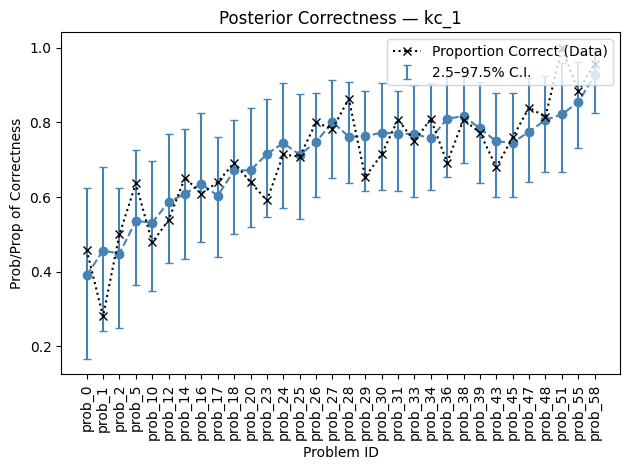

In [ ]:
# probability of correctness (with credible intervals)
plot_posterior_correctness(
    posterior_pred_kc=pred_post_draws["kc_1"],
    data=data_df,
    kc="kc_1",
    type="probs",
    trajectory=True,
    frac=1,  # all problems
)

<Axes: title={'center': 'Posterior Correctness — kc_1'}, xlabel='Problem ID', ylabel='Proportion Correct'>

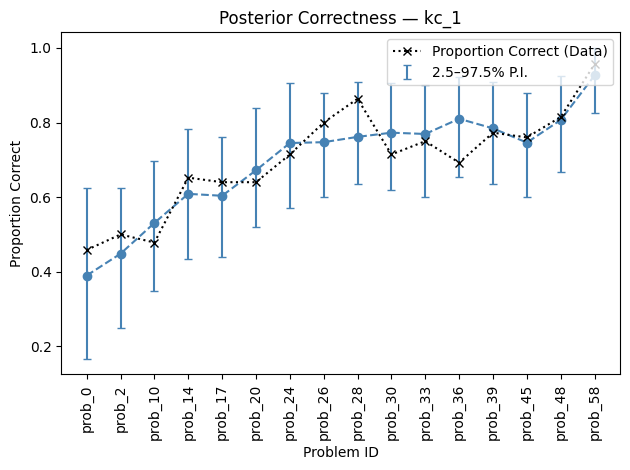

In [ ]:
# correctness predictions (with predictive intervals)
plot_posterior_correctness(
    posterior_pred_kc=pred_post_draws["kc_1"],
    data=data_df,
    posterior_pred_kc=pred_post_draws["kc_1"],
    kc="kc_1",
    type="preds",
    trajectory=True,
    frac=0.5,
)